In [382]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import scipy.stats as stats

### 1. Import claims_data.csv and cust_data.csv which is provided to you and combine the two datasets appropriately to create a 360-degree view of the data. Use the same for the subsequent questions

In [292]:
cust=pd.read_csv("D:\\Analytic_X_lab\\Python\\Assigment\\Python Foundation Case Study 3 - Insurance Claims Case Study\Case Study 3 - Insurance Claims Case Study\\cust_demographics.csv")
cust.head(2)

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver


In [293]:
claim=pd.read_csv("D:\\Analytic_X_lab\\Python\\Assigment\\Python Foundation Case Study 3 - Insurance Claims Case Study\\Case Study 3 - Insurance Claims Case Study\\claims.csv")
claim.head(3)

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes


### 2. Perform a data audit for the datatypes and find out if there are any mismatch within the current datatypes of the columns and their business significance.

In [294]:
cust.info()
cust['DateOfBirth']=pd.to_datetime(cust.DateOfBirth,format='%d-%b-%y')
cust.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CUST_ID      1085 non-null   int64 
 1   gender       1085 non-null   object
 2   DateOfBirth  1085 non-null   object
 3   State        1085 non-null   object
 4   Contact      1085 non-null   object
 5   Segment      1085 non-null   object
dtypes: int64(1), object(5)
memory usage: 51.0+ KB


CUST_ID        0
gender         0
DateOfBirth    0
State          0
Contact        0
Segment        0
dtype: int64

In [295]:

claim.info()
claim['claim_date']=pd.to_datetime(claim.claim_date,format='%m/%d/%Y')
claim.isna().sum()
claim['claim_amount_ ']=pd.to_numeric(claim['claim_amount'].str.replace('$','',regex=False).str.replace(',', '', regex=False) )
claim.isna().sum()/claim.shape[0] *100
claim.drop(['claim_amount'],axis=1,inplace=True)
num=claim.select_dtypes(include=['float64']).columns
claim[num]=claim[num].apply(lambda x:x.fillna(x.mean()) )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1100 non-null   int64  
 1   customer_id          1100 non-null   int64  
 2   incident_cause       1100 non-null   object 
 3   claim_date           1100 non-null   object 
 4   claim_area           1100 non-null   object 
 5   police_report        1100 non-null   object 
 6   claim_type           1100 non-null   object 
 7   claim_amount         1035 non-null   object 
 8   total_policy_claims  1090 non-null   float64
 9   fraudulent           1100 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 86.1+ KB


### 3. Convert the column claim_amount to numeric. Use the appropriate modules/attributes to remove the $ sign.

In [296]:
#clam['claim_amount_']=pd.to_numeric(clam['claim_amount'].str.replace('$','',regex=False).str.replace(',', '', regex=False) )

## data Combining


In [297]:
cust_claim=pd.merge(left=cust,right=claim,how='left',left_on='CUST_ID',right_on='customer_id')

In [298]:
cust_claim.drop('customer_id',axis=1,inplace=True)


### 4. Of all the injury claims, some of them have gone unreported with the police. Create an alert flag (1,0) for all such claims.

In [299]:
cust_claim['Alert_flag']=np.where(cust_claim.police_report=='No',1,0)
cust_claim

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,total_policy_claims,fraudulent,claim_amount_,Alert_flag
0,21868593,Female,1979-01-12,VT,789-916-8172,Platinum,54004764.0,Driver error,2017-11-27,Auto,No,Material only,1.0,No,2980.0,1
1,75740424,Female,1970-01-13,ME,265-543-1264,Silver,33985796.0,Crime,2018-10-03,Home,Unknown,Material only,3.0,No,2980.0,0
2,30308357,Female,1984-03-11,TN,798-631-4758,Silver,53522022.0,Other driver error,2018-02-02,Auto,No,Material only,1.0,Yes,3369.5,1
3,30308357,Female,1984-03-11,TN,798-631-4758,Silver,63017412.0,Driver error,2018-04-04,Auto,No,Material only,6.0,No,1950.0,1
4,47830476,Female,1986-05-01,MA,413-187-7945,Silver,13015401.0,Natural causes,2018-06-17,Auto,No,Material only,1.0,No,1680.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,79539873,Female,1981-03-15,ND,459-425-4319,Platinum,62020796.0,Other driver error,2018-09-06,Auto,Yes,Material only,1.0,No,1770.0,0
1088,42364152,Female,1996-07-07,ID,529-462-1635,Silver,63269067.0,Other causes,2017-05-09,Home,No,Material only,1.0,No,2800.0,1
1089,19888166,Male,1990-04-11,WI,712-651-9613,Gold,22690595.0,Other driver error,2017-05-15,Auto,Yes,Injury only,2.0,No,33080.0,0
1090,11256802,Female,2064-10-22,LA,469-345-5617,Silver,12376894.0,Other driver error,2017-04-18,Auto,No,Material only,4.0,No,2840.0,1


### 5.  One customer can claim for insurance more than once and in each claim,multiple categories of claims can be involved. However, customer ID should remain unique. Retain the most recent observation and delete any duplicated records inthe data based on the customer ID column.

In [300]:
h=cust_claim.sort_values('claim_date',ascending=False)
h.drop_duplicates(keep='first',subset='CUST_ID').reset_index()
h

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,total_policy_claims,fraudulent,claim_amount_,Alert_flag
286,93915431,Male,2067-09-08,ME,134-785-1687,Gold,99775483.0,Other causes,2018-10-30,Auto,No,Material and injury,1.0,Yes,42124.500000,1
354,38011078,Female,1976-05-20,NE,271-123-1475,Gold,98795403.0,Crime,2018-10-30,Auto,Unknown,Material only,1.0,No,1940.000000,0
1062,58451506,Male,2068-04-22,FL,673-574-7823,Gold,43042986.0,Natural causes,2018-10-30,Auto,No,Material only,1.0,No,2420.000000,1
948,46710738,Male,1977-04-28,MO,962-834-9361,Gold,74761374.0,Driver error,2018-10-30,Auto,No,Material only,1.0,No,1830.000000,1
322,77510822,Female,1986-03-18,AK,436-934-7156,Silver,87329176.0,Other driver error,2018-10-30,Auto,Unknown,Material only,2.0,No,12442.125121,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,74888099,Male,1980-07-22,CO,125-613-7698,Platinum,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0
636,36009093,Female,1984-06-04,SC,264-374-5794,Platinum,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0
637,60016590,Female,1984-05-25,NV,649-742-8132,Silver,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0
638,96861647,Female,1996-08-06,NH,495-732-2638,Silver,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0


In [301]:
# Extracting Age from the date0fbirth columns
today=dt.datetime.today()
cust_claim['Age_cust']=((today-cust_claim.DateOfBirth).dt.days/365).astype(int)


# Creating bins 
cust_claim['Group_cust']=pd.cut(
    cust_claim.Age_cust,bins=[0,18,30,60,float('inf')],labels=['Children','Youth','Adult','Senior'],right=False
)




## 8. What is the average amount claimed by the customers from various segments?

In [302]:
cust_claim.groupby('Segment')['claim_amount_ '].mean().reset_index().round({'claim_amount_ ' : 2})


,Segment,claim_amount_
0,Gold,12828.13
1,Platinum,12340.89
2,Silver,12206.38


# 9. What is the total claim amount based on incident cause for all the claims that have been done at least 20 days prior to 1st of October, 2018.

In [303]:
p=cust_claim.loc[(cust_claim.claim_date <='2018-09-11') ]
h=p.groupby('incident_cause')['claim_amount_ '].sum().reset_index().sort_values('claim_amount_ ',ascending=True ,ignore_index=True).round({'claim_amount_ ':2})
h

,incident_cause,claim_amount_
0,Crime,724320.63
1,Natural causes,1313890.63
2,Other driver error,3318437.63
3,Driver error,3319645.50
4,Other causes,3724499.38


### 10. How many adults from TX, DE and AK claimed insurance for driver related issues and causes? 

In [304]:
p=cust_claim.loc[(cust_claim.State.isin(['TX','DE','AK']) )&(cust_claim.incident_cause.isin(['Other driver error','Driver error'])) & (cust_claim.Group_cust=='Adult')]
h=p.groupby('State')['Group_cust'].count().reset_index().sort_values('Group_cust',ascending=False,ignore_index=True)
h.rename(columns={'Group_cust':'No_of_Adult'},inplace=True)
h

,State,No_of_Adult
0,DE,10
1,AK,9
2,TX,7


# 11. Draw a pie chart between the aggregated value of claim amount based on gender and segment. Represent the claim amount as a percentage on the pie chart

<Axes: ylabel='claim_amount_ '>

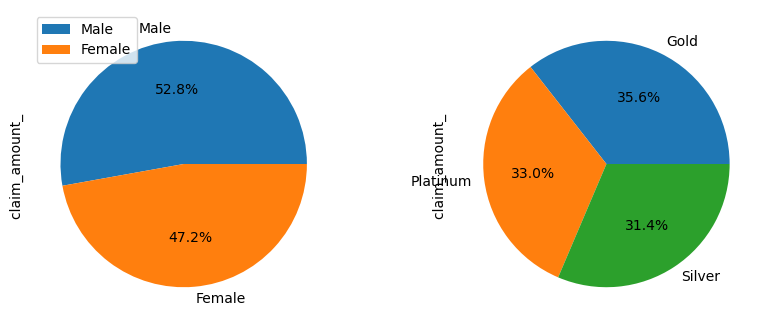

In [305]:
Gender=cust_claim.groupby('gender')['claim_amount_ '].sum().reset_index().sort_values('claim_amount_ ',ascending=False,ignore_index=True).round({'claim_amount_ ':2})
Segment=cust_claim.groupby('Segment')['claim_amount_ '].sum().reset_index().sort_values('claim_amount_ ',ascending=False,ignore_index=True).round({'claim_amount_ ':2})

# Gender by aggregated value of claim amount
fig, ax = plt.subplots(1,2 , figsize=(10, 4))
Gender.plot(kind='pie',y='claim_amount_ ',ax=ax[0],autopct='%1.1f%%',labels=['Male','Female'])

# Segment by aggregated value of claim amount
Segment.plot(kind='pie',y='claim_amount_ ',ax=ax[1],autopct='%1.1f%%',labels=['Gold','Platinum','Silver'],legend=False)



# 12. Among males and females, which gender had claimed the most for any type of driver related issues? E.g. This metric can be compared using a bar chart


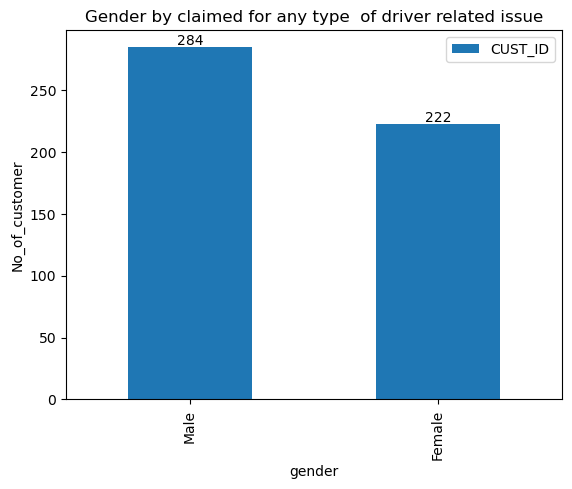

In [306]:
bar=cust_claim.loc[cust_claim.incident_cause.isin(['Driver error','Other driver error'])]
b=bar.groupby('gender')['CUST_ID'].count().reset_index().sort_values('CUST_ID',ascending=False,ignore_index=True)
t=b.plot(kind='bar',y='CUST_ID',x='gender')
plt.title('Gender by claimed for any type  of driver related issue')
plt.ylabel('No_of_customer')


for container in t.containers:
    t.bar_label(container)



# 13. Which age group had the maximum fraudulent policy claims? Visualize it on a bar chart.

C:\Users\Asus\AppData\Local\Temp\ipykernel_13016\3588299004.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  u=c.groupby('Group_cust')['CUST_ID'].count().reset_index().sort_values('CUST_ID',ascending=False,ignore_index=True)


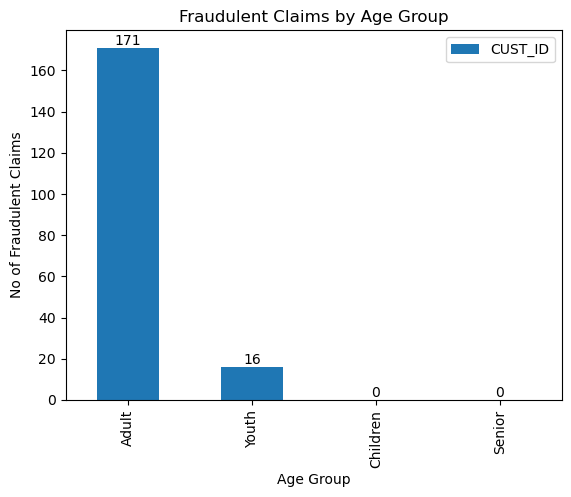

In [307]:



c=cust_claim.loc[cust_claim.fraudulent=='Yes']
u=c.groupby('Group_cust')['CUST_ID'].count().reset_index().sort_values('CUST_ID',ascending=False,ignore_index=True)
t=u.plot(kind='bar',x='Group_cust',y='CUST_ID')

for container in t.containers:
    t.bar_label(container)

plt.title('Fraudulent Claims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('No of Fraudulent Claims')
plt.show()

# 14. Visualize the monthly trend of the total amount that has been claimed by the customers. Ensure that on the “month” axis, the month is in a chronological order not alphabetical order.   

<Axes: xlabel='claim_Month'>

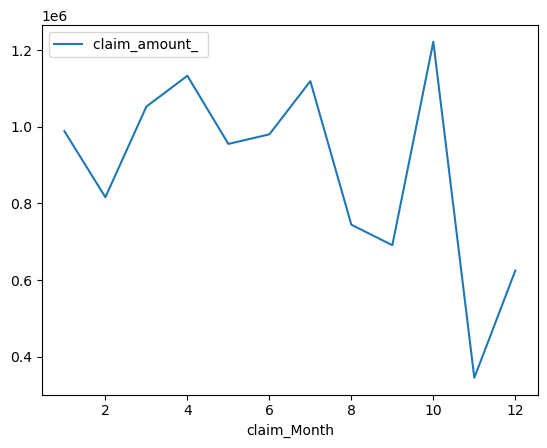

In [392]:
cust_claim['claim_Month']=cust_claim.claim_date.dt.month

p=cust_claim.groupby('claim_Month')['claim_amount_ '].sum().reset_index().sort_values('claim_Month',ascending=True,ignore_index=True).round({'claim_amount_ ':2})


p.plot(kind='line',x='claim_Month',y='claim_amount_ ',)


# 15. What is the average claim amount for gender and age categories and suitably represent the above using a facetted bar chart, one facet that represents fraudulent claims and the other for non-fraudulent claims.


C:\Users\Asus\AppData\Local\Temp\ipykernel_13016\1295974755.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p = cust_claim.groupby(    ['fraudulent','Group_cust','gender'])['claim_amount_ '].mean().reset_index()


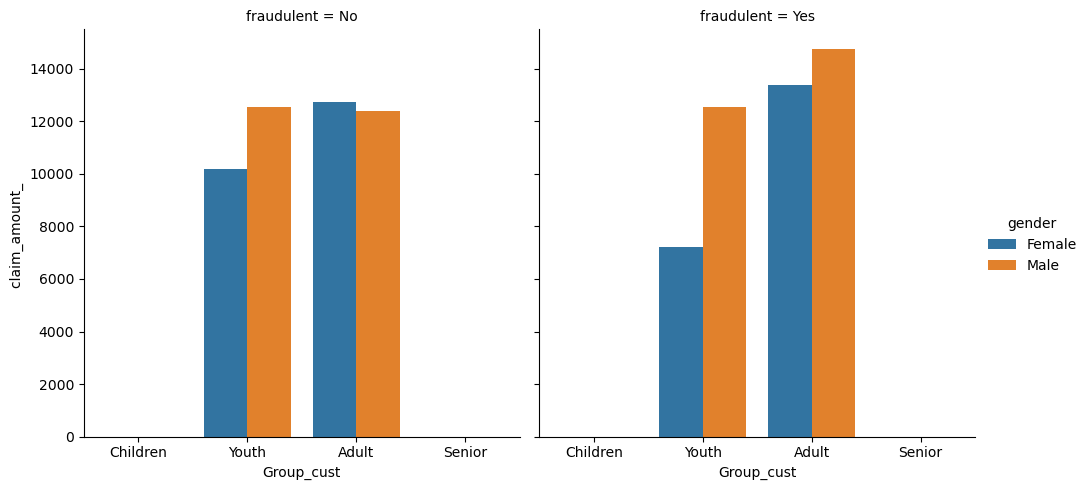

In [419]:
p = cust_claim.groupby(    ['fraudulent','Group_cust','gender'])['claim_amount_ '].mean().reset_index()
sns.catplot(data=p,x='Group_cust',y='claim_amount_ ', hue='gender',col='fraudulent',kind='bar', height=5,aspect=1)
plt.show()

# 16. Is there any similarity in the amount claimed by males and females?


### Define Null Hypothesis H0

     ** H0: There is no significant difference in the amount claimed by males and females.
     (μMale = μFemale)


### Define Alternate Hypothesis H1

        **  H1: There is a significant difference in the amount claimed by males and females.
        
           (μMale ≠ μFemale)
### At Confidence_Interval=95% ,Significane_Level(Alpha)=0.05

### Perfrom test:

    ** F-test as we want to compare the claim_amount for different Gender of the customers.



In [356]:
male=cust_claim.loc[cust_claim.gender=='Female','claim_amount_ ']
female=cust_claim.loc[cust_claim.gender=='Male','claim_amount_ ']

stats,p_val=stats.f_oneway(male,female)



In [357]:
# Rejection Rule:

if p_val < 0.05:
    print("Reject Null Hypothesis")
    print("There is a significant difference in the amount claimed by males and females.")
else:
    print("Fail to Reject Null Hypothesis")
    print("There is no significant difference in the amount claimed by males and females.")

# Bussiness Conclusion:

    # There is no significant difference in the amount claimed by males and females.
    Hence, the amount claimed by males and females is similar.

Fail to Reject Null Hypothesis


# 17. Is there any relationship between age category and segment?


### Define Null Hypothesis H0

        ** There is no Relationship Between Age_Category and Segment 

### Define Alternative Hypothesis H1

       ** There is Relationship Between Age_Category and Segment 

### At CI=95% ,Significance level (alpha)=0.05

### Perfrom Test;

    ** Chi-Square test as we want to check co-relations b/w 2 categorical columns
        

In [337]:
obs=pd.crosstab(index=cust_claim.Group_cust,columns=cust_claim.Segment)


statistic,p_value_,dof,expected_freq=stats.chi2_contingency(obs)



In [338]:
# Rejection Rule :
if p_value_ < 0.05:
    print('Reject Null Hypothesis') # Relationship exist
else:
    print('Fail to Reject Null Hypothesis ') # Relationship not exist

# Bussiness Conclusion:

   # There  is Relationship Between Age_Category and Segment


Fail to Reject Null Hypothesis 


# 18. The current year has shown a significant rise in claim amounts as compared to 2016-17 fiscal average which was $10,000.


### Define Null Hypothesis  H0

      The current year's average claim amount is equal to $10,000.
      μ = 10000

### Define Alternative Hypothesis H1

       The current year's average claim amount is greater than $10,000.
       μ > 10000
### AI CI=95% ,Significance_Level(Alpha)=0.05

### Perform Test:

      t_test

           


In [430]:
usage=cust_claim['claim_amount_ ']
p=10000

s,j=stats.ttest_1samp(usage,p)

In [431]:
### Rejection Rule:
if j < 0.05:
    
    print( 'Reject Null hypothesis is ') 
else:
    print('fail Reject Null Hypotheis') 
### Bussiness conclusion
         #The current year's average claim amount is significantly higher than the 2016–17 fiscal average of $10,000.
    

Reject Null hypothesis is 


# 19. Is there any difference between age groups and insurance claims?


### Define Null Hypothesis H0

    ** There is No Significence difference Between age_groups and claim_amount

### Define Alternate Hypothesis H1

         ** There is  Significence difference Between age_groups and claim_amount

### At CI=95% ,Significnce_Level(Alpha)=0.05

### Perfrom Test:

         ** ** F-test as we want to compare the  insurance_clam for different age_group of the customers.

          

In [377]:
Adult=cust_claim.loc[cust_claim.Group_cust=='Adult','claim_amount_ ']
Youth=cust_claim.loc[cust_claim.Group_cust=='Youth','claim_amount_ ']
Children=cust_claim.loc[cust_claim.Group_cust=='Children','claim_amount_ ']
Senior=cust_claim.loc[cust_claim.Group_cust=='Senior','claim_amount_ ']

t,p=stats.f_oneway(Adult,Youth)


In [376]:
### Rejection Rule:
if p < 0.05:
    
    print( 'Reject Null hypothesis is ') # 
else:
    print('fail Reject Null Hypotheis') # No Relationship exist

### Bussiness conclusion
    
        # There is Significence difference Between age_groups and claim_amount
#Children and Senior age groups did not have sufficient claim records.Therefore, the analysis was performed on the available age groups (Adult and Youth).

fail Reject Null Hypotheis


# 20. Is there any relationship between total number of policy claims and the claimed amount

#### Define Null Hypothesis H0
        There is no Relationship between Total_number_Of_Policy and claimed amount(p=0)
          
#### Define Alternate Hypothesis H1
           There is  Relationship between Total_number_Of_Policy and claimed amount(p!=0)
           

#### At Confident Interval 95% and p- value is 0.05

####  Perform the test:
        Pearson Co-efficient test as we want to check co-relations b/w 2 numerical columns


In [289]:
p=cust_claim['total_policy_claims']
h=cust_claim['claim_amount_ ']

stat,p_value=stats.pearsonr(p,h)




In [290]:
### Rejection Rule:
if p_value < 0.05:
    
    print( 'Reject Null hypothesis is ') # Relationship exist
else:
    print('fail Reject Null Hypotheis') # No Relationship exist

### Bussiness conclusion
    
        # There is  relationship between Total_number_Of_Policy and claimed amount

fail Reject Null Hypotheis
